# Exploratory Data Analysis: Daily Ridership Patterns

This notebook reads the cleaned trip-level dataset from `01_Data_Cleaning`, aggregates it to a **daily time series**, and explores the temporal patterns that will drive our demand forecasting models.

Key questions:
1. What does the overall daily ridership trend look like across 2023?
2. What weekly and seasonal patterns exist?
3. Is the series stationary? What lag structure does the data exhibit?
4. How do weekday/weekend and holiday effects manifest?
5. How does trip duration co-vary with demand volume?

In [11]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

sns.set_theme(style="whitegrid")

In [12]:
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / 'outputs' / 'data' / 'ridership_clean.parquet'
df = pd.read_parquet(DATA_PATH)
print(f"{len(df):,} trips loaded")

30,830,264 trips loaded


In [13]:
df.tail()

,Trip Duration,Start Station Id,Start Time,Start Station Name,End Station Id,End Time,End Station Name,Bike Id,User Type,year,Start Date,Start Hour,End Date,Trip_Duration_Min,Peak_Hour_Binary,User_Type_Binary
Trip Id,,,,,,,,,,,,,,,,
43436831,377,7271.0,23:55:58,Yonge St / Alexander St - SMART,7270.0,00:02:15,Church St / Dundas St E - SMART,9264.0,Casual Member,2025,2025-11-30,23,2025-12-01,6.283333,0,0
43436832,164,7281.0,23:56:00,Charles St W / Balmuto St - SMART,8118.0,23:58:44,Clover Hill Park - SMART,8834.0,Annual Member,2025,2025-11-30,23,2025-11-30,2.733333,0,1
43436833,776,7543.0,23:56:24,Nassau St / Bellevue Ave,7259.0,00:09:20,Lower Spadina Ave / Lake Shore Blvd W,7240.0,Annual Member,2025,2025-11-30,23,2025-12-01,12.933333,0,1
43436836,1471,7719.0,23:59:29,Wolseley St / Augusta Ave,7181.0,00:24:00,Lansdowne Ave / Whytock Ave,9370.0,Annual Member,2025,2025-11-30,23,2025-12-01,24.516667,0,1
43436838,223,7272.0,23:59:46,Yonge St / Dundonald St,7271.0,00:03:29,Yonge St / Alexander St - SMART,8720.0,Annual Member,2025,2025-11-30,23,2025-12-01,3.716667,0,1


### Aggregate to Daily Time Series

We use `src/feature_engineering.aggregate_daily` to collapse ~5.6M trips into 365 daily observations. This is our forecasting target: daily trip count.

In [14]:
from src.feature_engineering import aggregate_daily, add_calendar_features

daily = aggregate_daily(df)
daily = add_calendar_features(daily)

print(f"{len(daily)} days and {daily['trip_count'].sum():,} total trips")
print(f"Date range: {daily.index.min().date()} to {daily.index.max().date()}")
daily.head(10)

2192 days and 30,830,264 total trips
Date range: 2020-01-01 to 2025-12-31


,trip_count,mean_duration_min,median_duration_min,pct_annual_member,pct_peak_hour,day_of_week,month,day_of_year,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,is_weekend,is_holiday
date,,,,,,,,,,,,,,,,
2020-01-01,1340,12.244677,10.100000,0.826866,0.442537,2,1,1,0.974928,-0.222521,0.5,0.866025,0.017213,0.999852,0,1
2020-01-02,3742,11.349327,9.550000,0.921165,0.650722,3,1,2,0.433884,-0.900969,0.5,0.866025,0.034422,0.999407,0,0
2020-01-03,4364,11.289062,9.741667,0.906279,0.615490,4,1,3,-0.433884,-0.900969,0.5,0.866025,0.051620,0.998667,0,0
2020-01-04,2366,10.950754,9.133333,0.915469,0.444210,5,1,4,-0.974928,-0.222521,0.5,0.866025,0.068802,0.997630,1,0
2020-01-05,1958,10.783810,8.741667,0.930541,0.463739,6,1,5,-0.781831,0.623490,0.5,0.866025,0.085965,0.996298,1,0
2020-01-06,3639,10.800806,9.333333,0.970322,0.697719,0,1,6,0.000000,1.000000,0.5,0.866025,0.103102,0.994671,0,0
2020-01-07,4522,10.982073,9.450000,0.968598,0.689739,1,1,7,0.781831,0.623490,0.5,0.866025,0.120208,0.992749,0,0
2020-01-08,3447,10.988173,9.500000,0.959965,0.664926,2,1,8,0.974928,-0.222521,0.5,0.866025,0.137279,0.990532,0,0
2020-01-09,3514,10.869584,9.216667,0.963574,0.667331,3,1,9,0.433884,-0.900969,0.5,0.866025,0.154309,0.988023,0,0


In [15]:
# Descriptive statistics for daily trip counts
desc = daily['trip_count'].describe()
print(f"Mean: {desc['mean']:,.0f} trips/day")
print(f"Median: {desc['50%']:,.0f} trips/day")
print(f"Std: {desc['std']:,.0f}")
print(f"Min: {desc['min']:,.0f} ({daily['trip_count'].idxmin().date()})")
print(f"Max: {desc['max']:,.0f} ({daily['trip_count'].idxmax().date()})")

Mean: 14,065 trips/day
Median: 12,130 trips/day
Std: 9,598
Min: 155 (2025-02-16)
Max: 44,137 (2025-06-14)


### Daily Ridership Trend

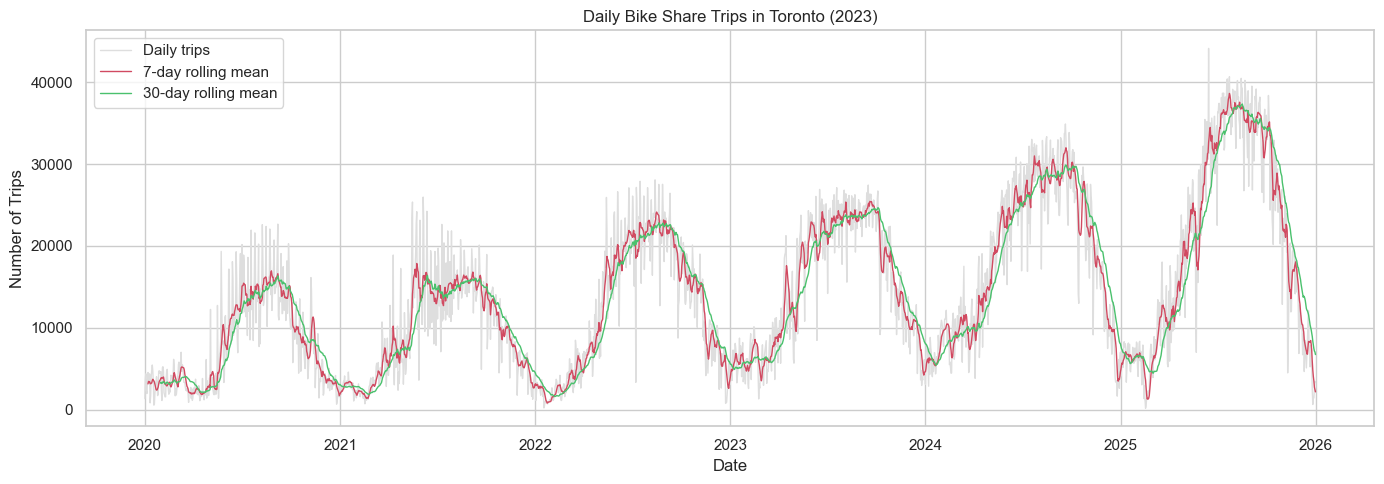

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily['trip_count'], color="#dedede", linewidth=1, label='Daily trips')

# 7-day rolling mean (Averages the last 7 days)
rolling7 = daily['trip_count'].rolling(7).mean()
ax.plot(daily.index, rolling7, color='#d14a61', linewidth=1, label='7-day rolling mean')

# 30-day rolling mean (Roughly a month)
rolling30 = daily['trip_count'].rolling(30).mean()
ax.plot(daily.index, rolling30, color='#4ac16d', linewidth=1, label='30-day rolling mean')

ax.set_title('Daily Bike Share Trips in Toronto (2023)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Trips')
ax.legend()
plt.tight_layout()
plt.show()

The total number of trips per year has increased

### Seasonal Decomposition

We decompose the daily series into trend, seasonal (weekly, period=7), and residual components using an additive model.

"A good way to get a feel of how each of these patterns behaves is to break the time series into many distinct components. The idea is that each component represents a specific pattern like trend, cycle, and seasonality." [Source](https://sthalles.github.io/a-visual-guide-to-time-series-decomposition/)

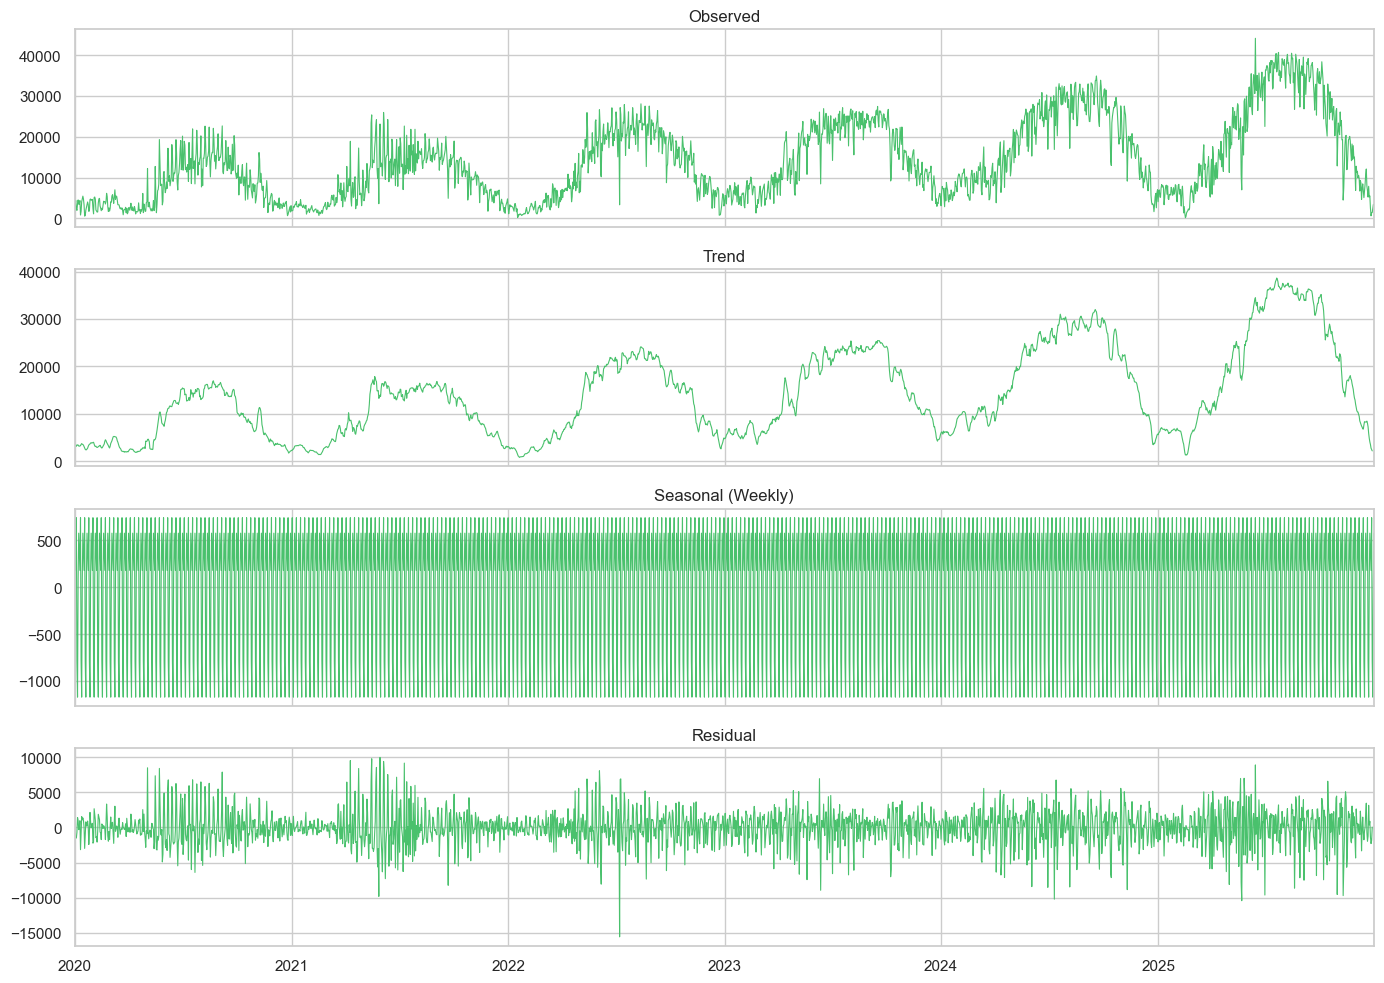

In [17]:
decomp = seasonal_decompose(daily['trip_count'], model='additive', period=7) # Produces three pieces
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

decomp.observed.plot(ax=axes[0], title='Observed', linewidth=0.8, color='#4ac16d')
decomp.trend.plot(ax=axes[1], title='Trend', linewidth=0.8, color="#4ac16d")
decomp.seasonal.plot(ax=axes[2], title='Seasonal (Weekly)', linewidth=0.8, color="#4ac16d")
decomp.resid.plot(ax=axes[3], title='Residual', linewidth=0.8, color="#4ac16d")

for ax in axes:
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

### Day-of-Week Patterns

In [18]:
# day_of_week already created by add_calendar_features() above
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

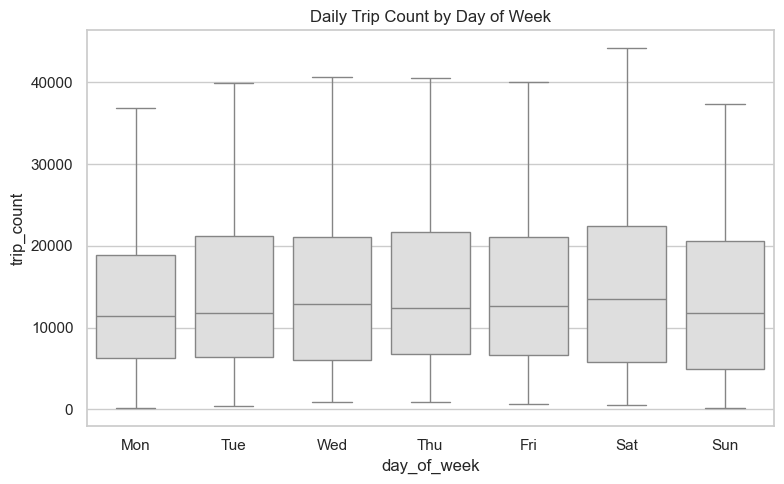

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=daily, x='day_of_week', y='trip_count', ax=ax, color='#dedede')

ax.set(xticks=range(7), xticklabels=day_names)

ax.set_title('Daily Trip Count by Day of Week')
plt.tight_layout()
plt.show()

### Monthly Patterns

        mean   median      sum
Jan   4438.0   4094.0   825554
Feb   4550.0   3492.0   773566
Mar   6710.0   5881.0  1248073
Apr   9769.0   9501.0  1758379
May  16108.0  17452.0  2996171
Jun  20657.0  20846.0  3718197
Jul  23101.0  22617.0  4296697
Aug  23644.0  23108.0  4397856
Sep  22891.0  22692.0  4120425
Oct  18031.0  17103.0  3353730
Nov  12254.0  11179.0  2205790
Dec   6107.0   5736.0  1135826


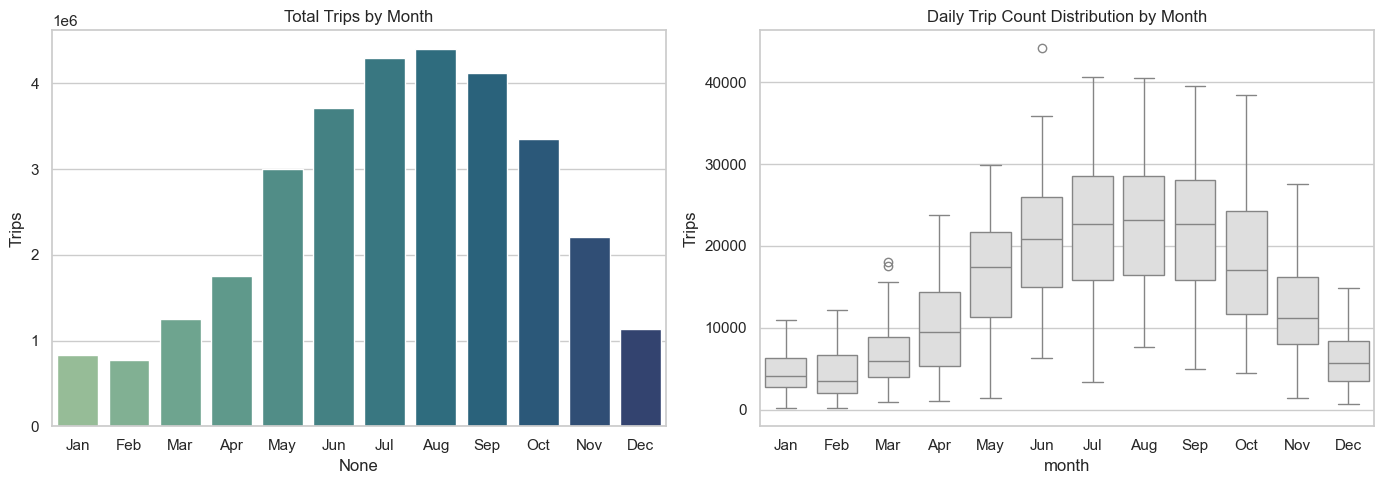

In [20]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_stats = daily.groupby('month')['trip_count'].agg(['mean', 'median', 'sum']).round(0)
monthly_stats.index = month_names
print(monthly_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total trips per month
sns.barplot(x=monthly_stats.index, 
            y=monthly_stats['sum'],
            hue=monthly_stats.index,
            legend=False,
            palette='crest',
            ax=axes[0]
)
axes[0].set_title('Total Trips by Month')
axes[0].set_ylabel('Trips')

# Box plot of daily counts by month
sns.boxplot(data=daily, x='month', y='trip_count', color='#dedede', ax=axes[1])
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_names)
axes[1].set_title('Daily Trip Count Distribution by Month')
axes[1].set_ylabel('Trips')

plt.tight_layout()
plt.show()

### Stationarity Testing

A stationary series has constant mean and variance over time. We run the Augmented Dickey-Fuller test on the raw daily counts and on the first-differenced series to understand the trend structure and inform whether differencing or detrending is needed for modeling.

In [21]:
def adf_report(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"{label}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.6f}")
    print(f"Lags used: {result[2]}")
    for k, v in result[4].items():
        print(f"Critical ({k}): {v:.4f}")
    verdict = 'Stationary' if result[1] < 0.05 else 'Non-stationary'
    print(f"to {verdict} (at 5% significance)\n")

adf_report(daily['trip_count'], 'Raw daily trip count')
adf_report(daily['trip_count'].diff(), 'First-differenced trip count')

Raw daily trip count
ADF Statistic: -2.3701
p-value: 0.150348
Lags used: 26
Critical (1%): -3.4334
Critical (5%): -2.8629
Critical (10%): -2.5675
to Non-stationary (at 5% significance)

First-differenced trip count
ADF Statistic: -8.9094
p-value: 0.000000
Lags used: 26
Critical (1%): -3.4334
Critical (5%): -2.8629
Critical (10%): -2.5675
to Stationary (at 5% significance)



### ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function)

ACF and PACF plots reveal the lag structure in the data. Significant spikes tell us which past days are most predictive of today. This directly informs which lag features to engineer for the models.

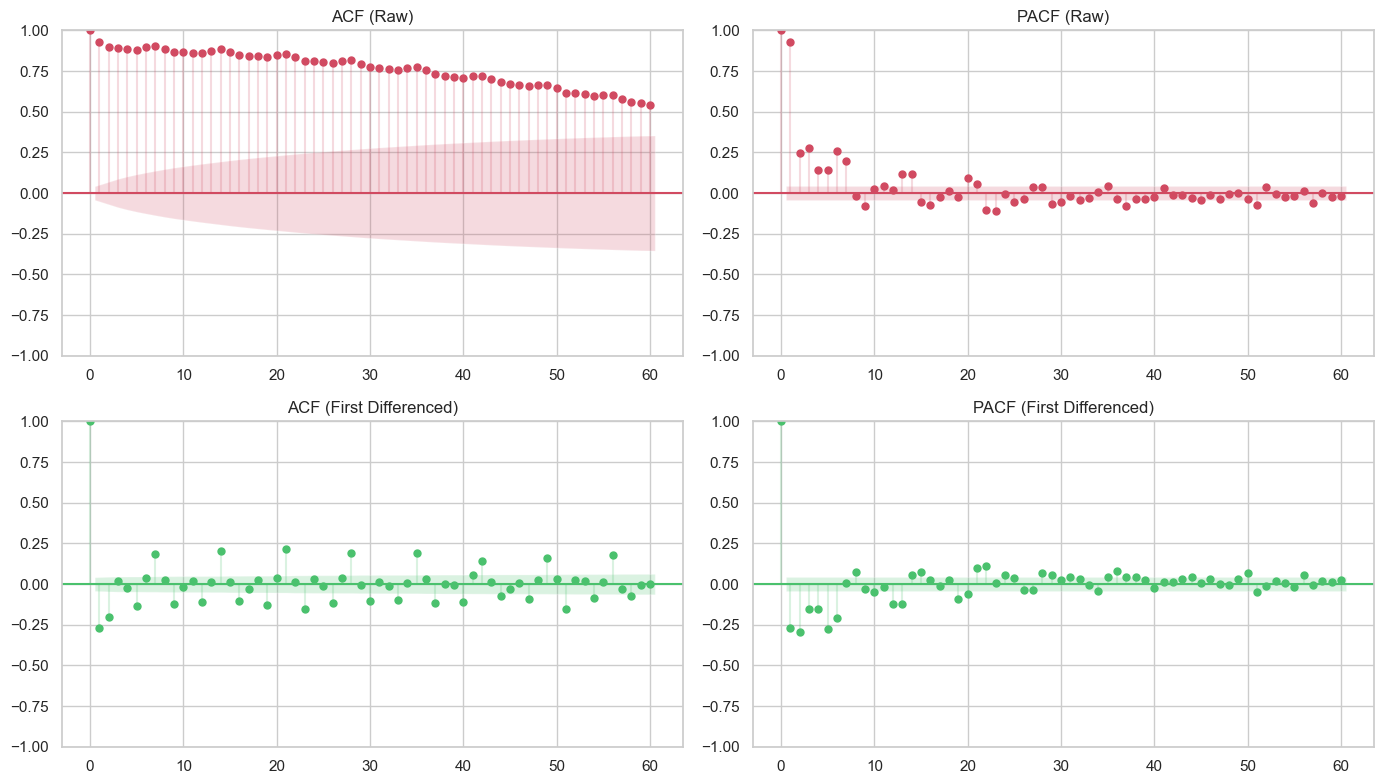

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(daily['trip_count'].dropna(), lags=60, ax=axes[0, 0], title='ACF (Raw)', color='#d14a61', vlines_kwargs={'colors':'#d14a61'})
plot_pacf(daily['trip_count'].dropna(), lags=60, ax=axes[0, 1], title='PACF (Raw)', color='#d14a61', vlines_kwargs={'colors':'#d14a61'})

for patch in axes[0, 0].collections:
    patch.set_facecolor('#d14a61')
    patch.set_alpha(0.2)
for patch in axes[0, 1].collections:
    patch.set_facecolor('#d14a61')
    patch.set_alpha(0.2)

first_differencing = daily['trip_count'].diff().dropna() # Subtracts each day's trip count from the previous day's
plot_acf(first_differencing, lags=60, ax=axes[1, 0], title='ACF (First Differenced)', color='#4ac16d', vlines_kwargs={'colors':'#4ac16d'})
plot_pacf(first_differencing, lags=60, ax=axes[1, 1], title='PACF (First Differenced)', color='#4ac16d', vlines_kwargs={'colors':'#4ac16d'})

# Confidence band
for patch in axes[1, 0].collections:
    patch.set_facecolor('#4ac16d')
    patch.set_alpha(0.2)
for patch in axes[1, 1].collections:
    patch.set_facecolor('#4ac16d')
    patch.set_alpha(0.2)

plt.tight_layout()
plt.show()

### Weekend and Holiday

             mean   median  count
day_type                         
Holiday    9938.0   5347.0     58
Weekday   14189.0  12134.0   1515
Weekend   14147.0  13044.0    619


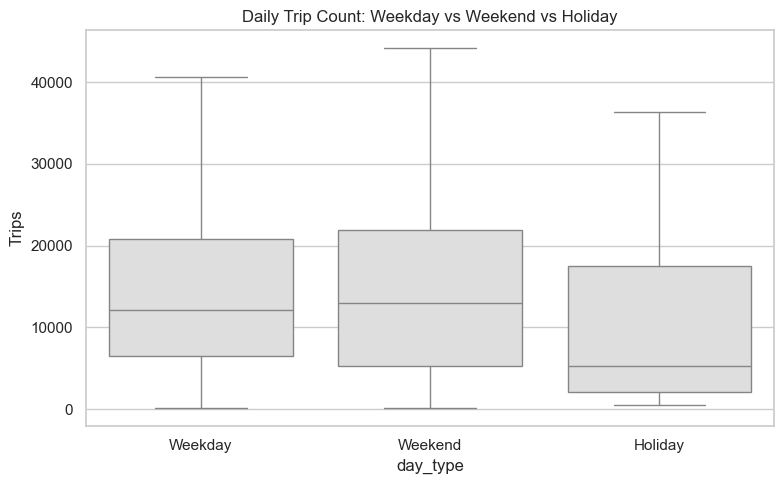

In [23]:
# Create a combined category for comparison
conditions = [daily['is_holiday'] == 1, daily['is_weekend'] == 1]
labels = ['Holiday', 'Weekend']
daily['day_type'] = np.select(conditions, labels, default='Weekday')

day_type_stats = daily.groupby('day_type')['trip_count'].agg(['mean', 'median', 'count']).round(0)
print(day_type_stats)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=daily, x='day_type', y='trip_count', color='#dedede', order=['Weekday', 'Weekend', 'Holiday'], ax=ax)
ax.set_title('Daily Trip Count: Weekday vs Weekend vs Holiday')
ax.set_ylabel('Trips')
plt.tight_layout()
plt.show()

### Trip Duration vs. Demand Volume

Do high-demand days tend to have shorter or longer average trips?

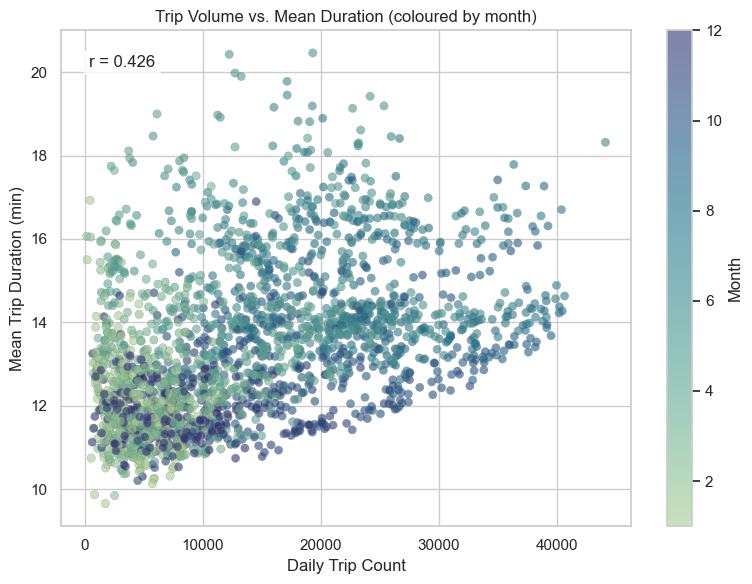

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    daily['trip_count'],
    daily['mean_duration_min'],
    c=daily['month'],
    cmap='crest',
    alpha=0.6,
    edgecolors='grey',
    linewidth=0.3
)

plt.colorbar(sc, label='Month')
ax.set_xlabel('Daily Trip Count')
ax.set_ylabel('Mean Trip Duration (min)')
ax.set_title('Trip Volume vs. Mean Duration (coloured by month)')

r = daily[['trip_count', 'mean_duration_min']].corr().iloc[0, 1]
ax.annotate(f'r = {r:.3f}', 
            xy=(0.05, 0.95),
            xycoords='axes fraction',
            fontsize=12, 
            ha='left',
            va='top',
            bbox=dict(boxstyle='round', fc='white',alpha=0.8)
)

plt.tight_layout()
plt.show()

### Visualize Cyclical Encodings

Cyclical sin/cos transforms ensure the model knows that Monday is close to Sunday, and December is close to January.

A model can now measure the distance between two dates geometrically using these sin/cos pairs, and that distance will correctly reflect how close they are in the calendar cycle — something raw numbers can never do.

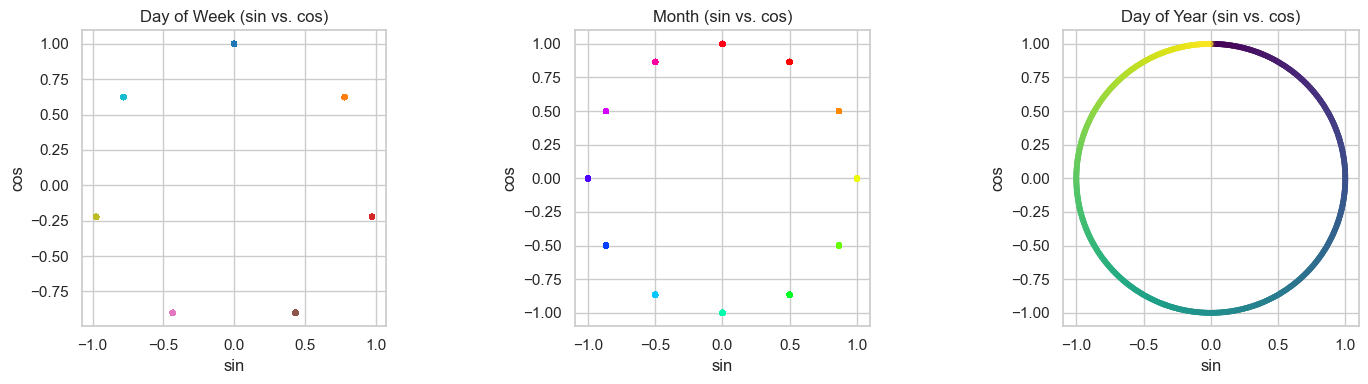

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Day of week
axes[0].scatter(daily['day_of_week_sin'], daily['day_of_week_cos'], c=daily['day_of_week'], cmap='tab10', alpha=0.5, s=10)
axes[0].set_title('Day of Week (sin vs. cos)')
axes[0].set_xlabel('sin'); axes[0].set_ylabel('cos')
axes[0].set_aspect('equal')

# Month
axes[1].scatter(daily['month_sin'], daily['month_cos'], c=daily['month'], cmap='hsv', alpha=0.5, s=10)
axes[1].set_title('Month (sin vs. cos)')
axes[1].set_xlabel('sin'); axes[1].set_ylabel('cos')
axes[1].set_aspect('equal')

# Day of year
axes[2].scatter(daily['day_of_year_sin'], daily['day_of_year_cos'], c=daily['day_of_year'], cmap='viridis', alpha=0.5, s=10)
axes[2].set_title('Day of Year (sin vs. cos)')
axes[2].set_xlabel('sin'); axes[2].set_ylabel('cos')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

### Lag Feature Correlations

How well do past trip counts predict today's count?

Correlation of lag/rolling features with trip_count:

trip_count_rmean7     0.9401
trip_count_rmean14    0.9350
trip_count_lag1       0.9303
trip_count_rmean28    0.9175
trip_count_lag7       0.9092
trip_count_lag14      0.8905
trip_count_lag28      0.8266
Name: trip_count, dtype: float64


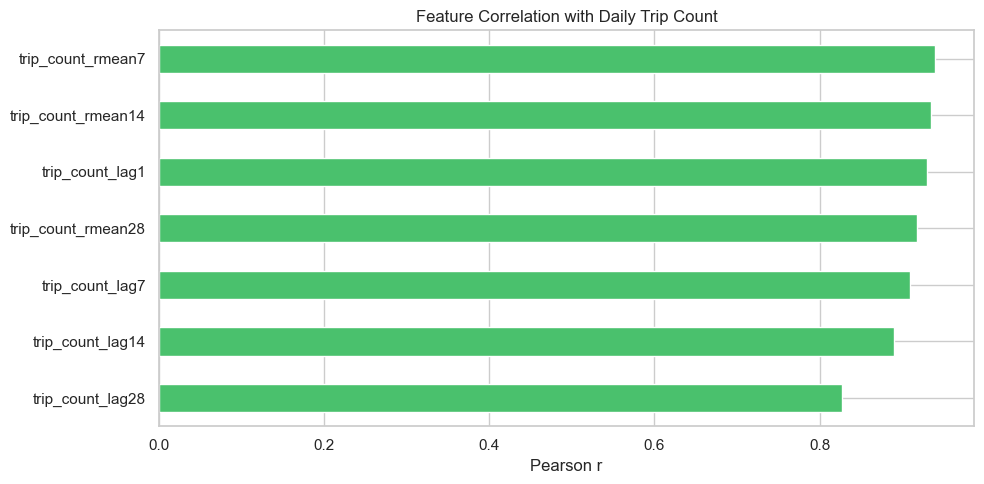

In [26]:
from src.feature_engineering import add_lag_features, add_rolling_features

daily = add_lag_features(daily)
daily = add_rolling_features(daily)

lag_cols = [c for c in daily.columns if 'lag' in c or 'rmean' in c]
corr_with_target = daily[lag_cols + ['trip_count']].corr()['trip_count'].drop('trip_count').sort_values(ascending=False)

print("Correlation of lag/rolling features with trip_count:\n")
print(corr_with_target.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
corr_with_target.plot(kind='barh', ax=ax, color='#4ac16d')
ax.set_title('Feature Correlation with Daily Trip Count')
ax.set_xlabel('Pearson r')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Full Feature Correlation Heatmap

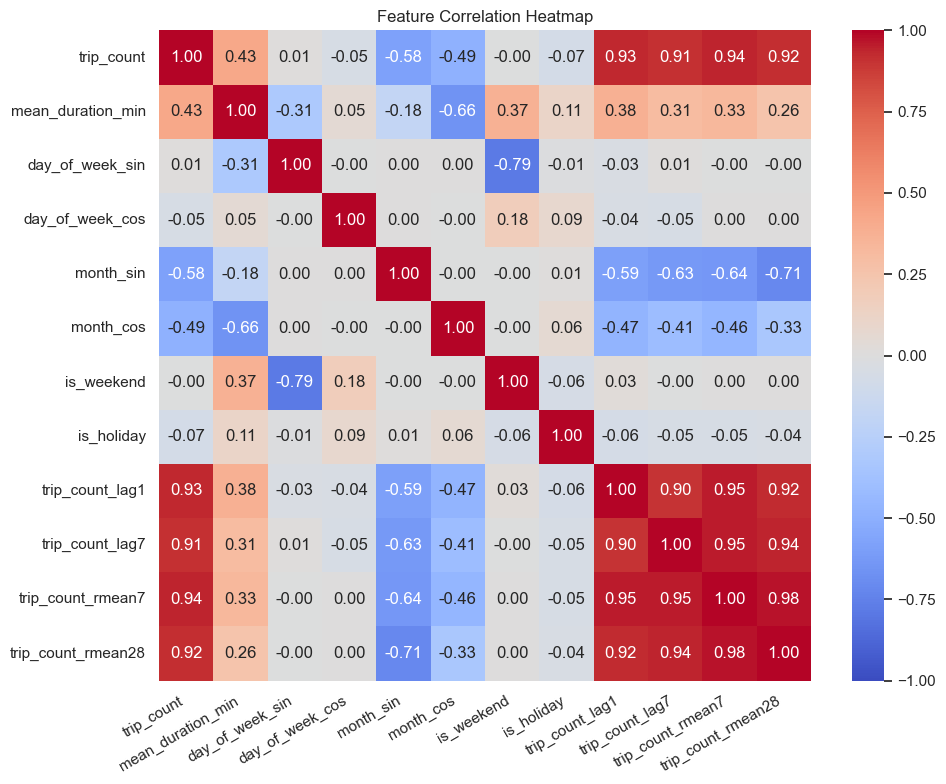

In [27]:
# Select a subset of key features to keep the heatmap readable
key_features = [
    'trip_count',
    'mean_duration_min',
    'day_of_week_sin',
    'day_of_week_cos',
    'month_sin',
    'month_cos',
    'is_weekend',
    'is_holiday',
    'trip_count_lag1',
    'trip_count_lag7',
    'trip_count_rmean7',
    'trip_count_rmean28'
]
key_features = [c for c in key_features if c in daily.columns]

corr = daily[key_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap')
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

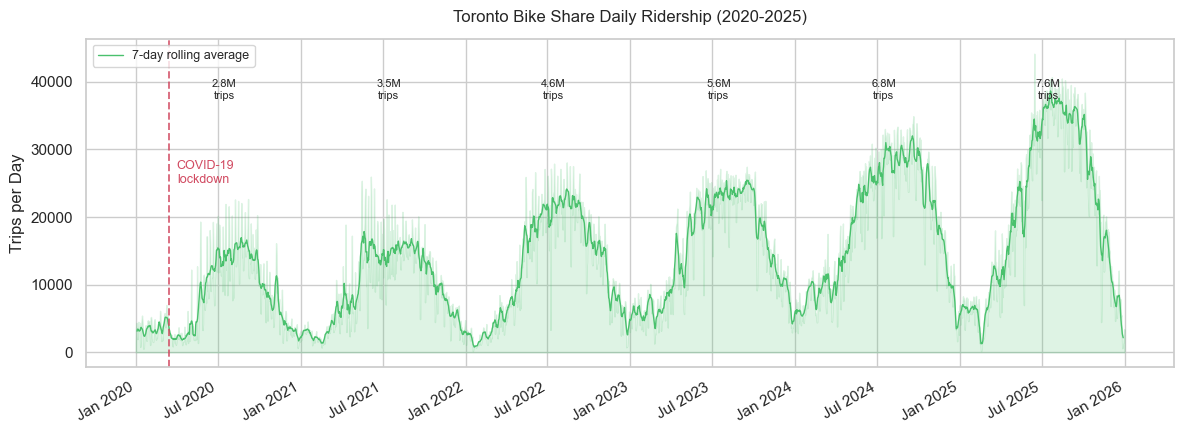

In [28]:
fig, ax = plt.subplots(figsize=(12, 4.5))

roll7 = daily["trip_count"].rolling(7, center=True).mean()
ax.fill_between(daily.index, daily["trip_count"], alpha=0.18, color='#4ac16d')
ax.plot(daily.index, roll7, color='#4ac16d', linewidth=1, label="7-day rolling average")

ax.axvline(pd.Timestamp("2020-03-15"), color='#d14a61', linestyle='dashed',
           linewidth=1.4, alpha=0.8)
ax.annotate(
    "COVID-19\nlockdown",
    xy=(pd.Timestamp("2020-03-15"), 2000),
    xytext=(pd.Timestamp("2020-04-01"), 25000),
    fontsize=9, 
    color='#d14a61'
)

yearly = daily.groupby(daily.index.year)["trip_count"].sum()
for yr, total in yearly.items():
    ax.text(
        pd.Timestamp(f"{yr}-07-15"), 
        roll7.max() * 0.97,
        f"{total / 1e6:.1f}M\ntrips",
        ha="center", 
        fontsize=8
    )

ax.set_title("Toronto Bike Share Daily Ridership (2020-2025)", pad=12)
ax.set_ylabel("Trips per Day")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=30, ha="right")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

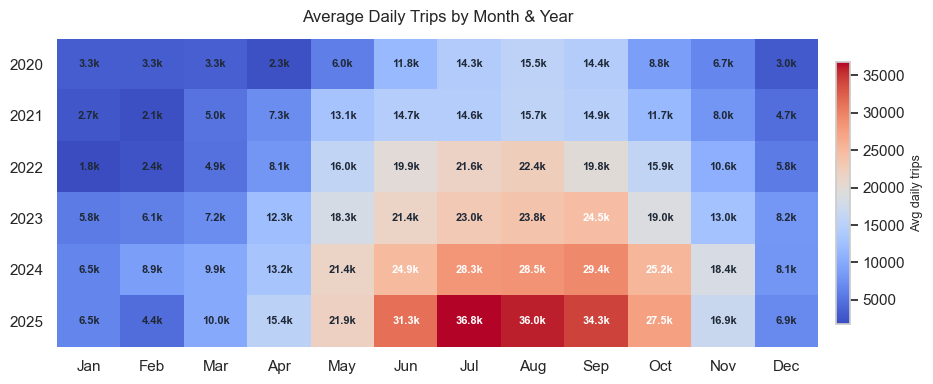

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))

pivot = daily.groupby([daily.index.year, daily.index.month])["trip_count"].mean().unstack()
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
pivot.columns = month_labels

im = ax.imshow(pivot.values, aspect="auto", cmap='coolwarm', interpolation="nearest")
ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title("Average Daily Trips by Month & Year", pad=12)

for i in range(len(pivot.index)):
    for j in range(12):
        val = pivot.values[i, j]
        if not np.isnan(val):
            txt_color = "white" if val > pivot.values.max() * 0.65 else "#1f2937"
            ax.text(j, i, f"{val / 1000:.1f}k", ha="center", va="center",
                    fontsize=8, color=txt_color, fontweight="bold")

cbar = plt.colorbar(im, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label("Avg daily trips", fontsize=9)
ax.spines[:].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

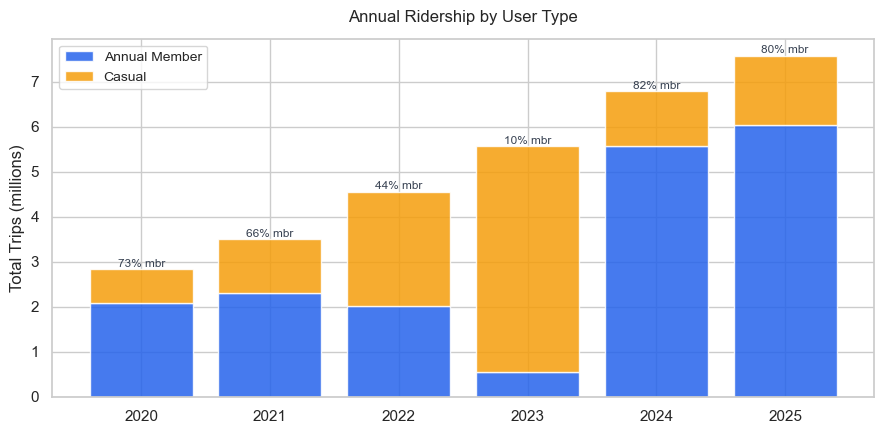

In [30]:
fig, ax = plt.subplots(figsize=(9, 4.5))

annual = daily.groupby(daily.index.year).agg(
    total=("trip_count", "sum"),
    pct_member=("pct_annual_member", "mean"),
)
annual["member_trips"] = annual["total"] * annual["pct_member"]
annual["casual_trips"] = annual["total"] * (1 - annual["pct_member"])

x = np.arange(len(annual))
ax.bar(x, annual["member_trips"] / 1e6, label="Annual Member", color="#2563EB", alpha=0.85)
ax.bar(x, annual["casual_trips"] / 1e6, bottom=annual["member_trips"] / 1e6,
       label="Casual", color="#F59E0B", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(annual.index)
ax.set_ylabel("Total Trips (millions)")
ax.set_title("Annual Ridership by User Type", pad=12)
ax.legend(fontsize=10)

for i, (_, row) in enumerate(annual.iterrows()):
    ax.text(i, row["total"] / 1e6 + 0.05,
            f"{row['pct_member'] * 100:.0f}% mbr",
            ha="center", fontsize=8.5, color="#374151")

plt.tight_layout()
plt.show()